In [1]:
! pip install pandas


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
! pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
df = pd.read_csv('dataset/phishing_site_urls.csv')

In [7]:
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [8]:
df.shape

(549346, 2)

In [9]:
df.info

<bound method DataFrame.info of                                                       URL Label
0       nobell.it/70ffb52d079109dca5664cce6f317373782/...   bad
1       www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...   bad
2       serviciosbys.com/paypal.cgi.bin.get-into.herf....   bad
3       mail.printakid.com/www.online.americanexpress....   bad
4       thewhiskeydregs.com/wp-content/themes/widescre...   bad
...                                                   ...   ...
549341                                    23.227.196.215/   bad
549342                                 apple-checker.org/   bad
549343                                  apple-iclods.org/   bad
549344                                 apple-uptoday.org/   bad
549345                                  apple-search.info   bad

[549346 rows x 2 columns]>

In [10]:
df.isnull().sum()

URL      0
Label    0
dtype: int64

In [11]:
df.Label.value_counts()

Label
good    392924
bad     156422
Name: count, dtype: int64

In [12]:
! pip install nltk


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from nltk.tokenize import RegexpTokenizer

In [14]:
tokenizer = RegexpTokenizer(r'[A-Za-a]+')

In [15]:
df.URL[0]

'nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526'

In [16]:
tokenizer.tokenize(df.URL[0])

['a', 'S', 'P', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a']

In [17]:
tokenizer = RegexpTokenizer(r'[A-Za-z]+')

In [18]:
tokenizer.tokenize(df.URL[0])

['nobell',
 'it',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'login',
 'SkyPe',
 'com',
 'en',
 'cgi',
 'bin',
 'verification',
 'login',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'index',
 'php',
 'cmd',
 'profile',
 'ach',
 'outdated',
 'page',
 'tmpl',
 'p',
 'gen',
 'failed',
 'to',
 'load',
 'nav',
 'login',
 'access']

In [19]:
df['text_tokenized']=df.URL.map(lambda t: tokenizer.tokenize(t))

In [20]:
df.head()

,URL,Label,text_tokenized
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi..."


In [21]:
from nltk.stem.snowball import SnowballStemmer

In [22]:
stemmer = SnowballStemmer("english")

In [23]:
df['text_stemmed']=df['text_tokenized'].map(lambda l: [stemmer.stem(word) for word in l])

In [24]:
df.head()

,URL,Label,text_tokenized,text_stemmed
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide..."


In [25]:
df['text'] = df['text_stemmed'].map(lambda l: ' '.join(l))

In [26]:
df.head()

,URL,Label,text_tokenized,text_stemmed,text
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [27]:
good_sites = df[df.Label == 'good']
bad_sites = df[df.Label == 'bad']

In [28]:
good_sites

,URL,Label,text_tokenized,text_stemmed,text
18231,esxcc.com/js/index.htm?us.battle.net/noghn/en/...,good,"[esxcc, com, js, index, htm, us, battle, net, ...","[esxcc, com, js, index, htm, us, battl, net, n...",esxcc com js index htm us battl net noghn en r...
18232,wwweira¯&nvinip¿ncH¯wVö%ÆåyDaHðû/ÏyEùuË\nÓ6...,good,"[www, eira, nvinip, ncH, wV, yDaH, yE, u, rT, ...","[www, eira, nvinip, nch, wv, ydah, ye, u, rt, ...",www eira nvinip nch wv ydah ye u rt u g m i xz...
18233,'www.institutocgr.coo/web/media/syqvem/dk-óij...,good,"[www, institutocgr, coo, web, media, syqvem, d...","[www, institutocgr, coo, web, media, syqvem, d...",www institutocgr coo web media syqvem dk ij r ...
18234,Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,good,"[Y, ko, D, l, qt]","[y, ko, d, l, qt]",y ko d l qt
18236,ruta89fm.com/images/AS@Vies/1i75cf7b16vc<Fd16...,good,"[ruta, fm, com, images, AS, Vies, i, cf, b, vc...","[ruta, fm, com, imag, as, vie, i, cf, b, vc, f...",ruta fm com imag as vie i cf b vc f d b g sd v...
...,...,...,...,...,...
483590,youthleaguesusa.com/potomacsoccer/2011/Tournam...,good,"[youthleaguesusa, com, potomacsoccer, Tourname...","[youthleaguesusa, com, potomacsocc, tournament...",youthleaguesusa com potomacsocc tournament html
483591,zip-codes.com/,good,"[zip, codes, com]","[zip, code, com]",zip code com
483592,owens.edu/news-releases/?p=2052,good,"[owens, edu, news, releases, p]","[owen, edu, news, releas, p]",owen edu news releas p
483593,1.safesecureweb.com/egale/index.asp?item=1173,good,"[safesecureweb, com, egale, index, asp, item]","[safesecureweb, com, egal, index, asp, item]",safesecureweb com egal index asp item


In [29]:
! pip install wordcloud


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

def plot_wordcloud(text,
                   mask=None,
                   max_words=400,
                   max_font_size=120,
                   figure_size=(24.0, 16.0),
                   title=None,
                   title_size=40,
                   image_color=False):

    stopwords = set(STOPWORDS)

    more_stopwords = {'com', 'http'}
    stopwords = stopwords.union(more_stopwords)

    wordcloud = WordCloud(
        background_color='white',
        stopwords=stopwords,
        max_words=max_words,
        max_font_size=max_font_size,
        random_state=42,
        mask=mask
    )

    wordcloud.generate(text)

    plt.figure(figsize=figure_size)

    if image_color:
        image_colors = ImageColorGenerator(mask)

        plt.imshow(
            wordcloud.recolor(color_func=image_colors),
            interpolation="bilinear"
        )

        plt.title(
            title,
            fontdict={
                'size': title_size
            },
            verticalalignment='bottom'
        )

    else:
        plt.imshow(wordcloud)

        plt.title(
            title,
            fontdict={
                'size': title_size,
                'color': 'green'
            },
            verticalalignment='bottom'
        )

    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [31]:
all_text = ' '.join(good_sites['text'].tolist())

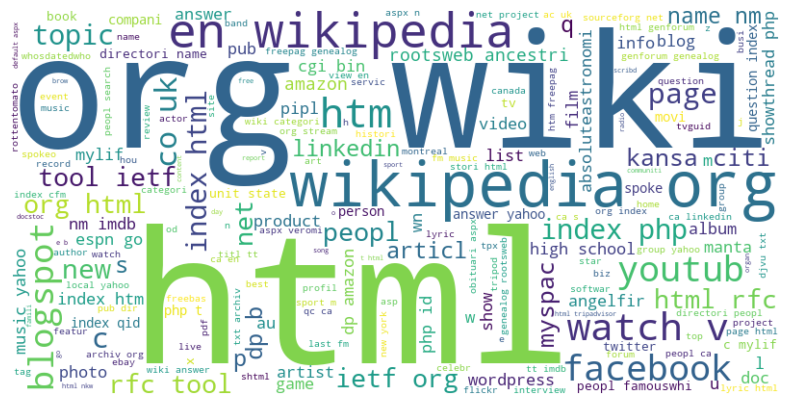

In [32]:
wordCloud = WordCloud(width=800,height=400,background_color='white').generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordCloud,interpolation='bilinear')
plt.axis('off')
plt.show()

In [33]:
all_text = ' '.join(bad_sites['text'].tolist())

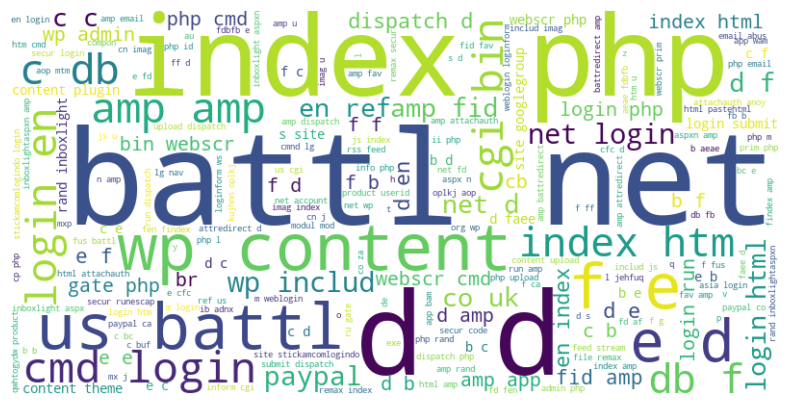

In [34]:
wordCloud = WordCloud(width=800,height=400,background_color='white').generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordCloud,interpolation='bilinear')
plt.axis('off')
plt.show()

In [35]:
df.head()

,URL,Label,text_tokenized,text_stemmed,text
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [36]:
! pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
from sklearn.feature_extraction.text import CountVectorizer

In [38]:
cv = CountVectorizer()

In [39]:
features = cv.fit_transform(df.text)

In [40]:
features[:5]

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 77 stored elements and shape (5, 350837)>

In [41]:
features[:5].toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5, 350837))

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
x_train, x_test, y_train, y_test = train_test_split(
    features,
    df.Label,
    test_size=0.2,
    random_state=42
)

In [44]:
x_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2941691 stored elements and shape (439476, 350837)>

Model Training

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
l_model = LogisticRegression()

In [47]:
l_model.fit(x_train,y_train)

C:\Users\aliva\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [48]:
l_model.score(x_test,y_test)

0.9643032674979521

In [49]:
l_model.score(x_train,y_train)

0.9786450227088623

In [50]:
from sklearn.metrics import classification_report

In [51]:
print('\nCLASSIFICATION REPORT\n')

print(
    classification_report(
        y_test,
        l_model.predict(x_test),
        target_names=['Bad', 'Good']
    )
)


CLASSIFICATION REPORT

              precision    recall  f1-score   support

         Bad       0.97      0.90      0.94     31200
        Good       0.96      0.99      0.98     78670

    accuracy                           0.96    109870
   macro avg       0.97      0.95      0.96    109870
weighted avg       0.96      0.96      0.96    109870



In [52]:
from sklearn.metrics import confusion_matrix

con_mat = pd.DataFrame(
    confusion_matrix(y_test, l_model.predict(x_test)),
    columns=['Predicted:Bad', 'Predicted:Good'],
    index=['Actual:Bad', 'Actual:Good']
)

print(con_mat)

             Predicted:Bad  Predicted:Good
Actual:Bad           28234            2966
Actual:Good            956           77714


In [53]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



CONFUSION MATRIX


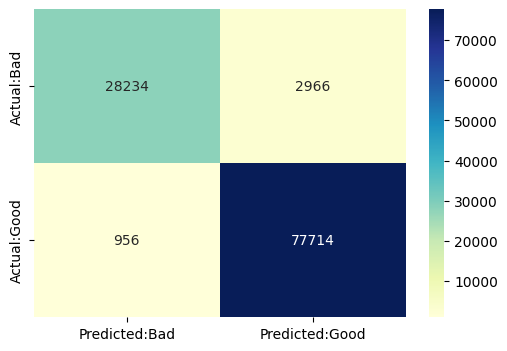

In [54]:
import seaborn as sns

print('\nCONFUSION MATRIX')

plt.figure(figsize=(6,4))

sns.heatmap(
    con_mat,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.show()

In [56]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()

In [57]:
mnb.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [58]:
mnb.score(x_test,y_test)

0.958359879858014

Save Model

In [59]:
import pickle

pickle.dump(l_model, open('phishing.pkl', 'wb'))

In [60]:
pickle.dump(cv, open('vectorizer.pkl', 'wb'))

In [61]:
bad_links = [
    "yeniik.com.tr/wp-admin/js/login.alibaba.com/login.jsp.php",
    "fazan-pacr.rs/temp/fii/adries/ipad",
    "www.tubemoviz.exe",
    "svision-online.de/mgfi/administrator/components/com_babackup/classes/fx29id1.txt"
]

good_links = [
    "www.youtube.com/",
    "youtube.com/watch?v=iqTQIJ3vdU",
    "www.retailmenotunderground.com/",
    "restorevisioncenters.com/html/technology.html"
]

In [62]:
predict_good = cv.transform(good_links)
predict_bad = cv.transform(bad_links)

In [63]:
l_model.predict(predict_good)

array(['good', 'good', 'good', 'good'], dtype=object)

In [64]:
l_model.predict(predict_bad)

array(['bad', 'bad', 'bad', 'bad'], dtype=object)

In [65]:
mnb.predict(predict_good)

array(['good', 'good', 'good', 'good'], dtype='<U4')

In [66]:
mnb.predict(predict_bad)

array(['bad', 'bad', 'bad', 'good'], dtype='<U4')

In [67]:
pickle.dump(mnb, open('phishing_mnb.pkl', 'wb'))

In [68]:
url = "fazan-pacr.rs/temp/fii/adries/ipad"
data = cv.transform([url])
prediction = l_model.predict(data)
if prediction == "bad":
    print("⚠️ Phishing URL Detected")
else:
    print("✅ Safe URL")

⚠️ Phishing URL Detected


In [69]:
url = "youtube.com"

# Convert URL into vector
data = cv.transform([url])

# Predict result
prediction = l_model.predict(data)[0]

# Predict confidence probability
probability = l_model.predict_proba(data)[0]

# Confidence score
confidence = round(max(probability) * 100, 2)

if prediction == "bad":
    print("⚠️ Phishing URL Detected")
else:
    print("✅ Safe URL")

print(confidence)

✅ Safe URL
79.55
